# Dataset Replay Lab

Purpose: inspect the Milestone 10 training-data path with deterministic windows, deterministic batch replay, and placeholder train/validation metrics.

Run path: `uv sync --extra research`, then open this notebook with `uv run jupyter lab notebooks` and run all cells. The notebook intentionally avoids requiring torch.

Fixture / simulated source: synthetic CSI windows shaped like replayable dataset samples, with state labels derived from sample index rather than randomness.

Expected interpretation: windows should show stable empty-room structure, stronger present-person reflections, and a motion state with time-varying ridges. Deterministic batches should repeat the same sample order for the same seed.

Limitations: the loss curves are synthetic placeholders, not evidence of model convergence. This notebook does not read MM-Fi, train PyTorch, or write checkpoints.


In [1]:
import importlib

import matplotlib.pyplot as plt
import numpy as np

try:
    ruview_training = importlib.import_module("ruview.training")
    training_note = "ruview.training import ok; using local NumPy replay helpers for this research notebook"
except Exception as exc:
    ruview_training = None
    training_note = f"Fallback NumPy replay path: {type(exc).__name__}: {exc}"

print(training_note)


ruview.training import ok; using local NumPy replay helpers for this research notebook


In [2]:
STATE_LABELS = ("empty", "present", "motion")


def deterministic_window(sample_idx, n_frames=64, n_subcarriers=56):
    state_idx = sample_idx % len(STATE_LABELS)
    state = STATE_LABELS[state_idx]
    time = np.linspace(0.0, 1.0, n_frames)
    subcarrier = np.linspace(-1.0, 1.0, n_subcarriers)
    tt, ss = np.meshgrid(time, subcarrier, indexing="ij")

    room_baseline = 0.32 + 0.08 * np.cos(2.0 * np.pi * (ss + 0.08 * sample_idx))
    slow_drift = 0.04 * np.sin(2.0 * np.pi * (tt * 0.7 + sample_idx * 0.03))
    present_reflection = 0.0
    motion_reflection = 0.0

    if state in {"present", "motion"}:
        center = -0.20 + 0.04 * (sample_idx % 4)
        present_reflection = 0.42 * np.exp(-((ss - center) ** 2) / (2.0 * 0.12**2))
    if state == "motion":
        moving_center = 0.35 * np.sin(2.0 * np.pi * (tt + sample_idx * 0.02))
        motion_reflection = 0.36 * np.exp(-((ss - moving_center) ** 2) / (2.0 * 0.095**2))

    window = room_baseline + slow_drift + present_reflection + motion_reflection
    window = (window - window.min()) / (window.max() - window.min())
    return {"sample_idx": sample_idx, "state": state, "time": time, "subcarrier": subcarrier, "window": window}


def make_replay_dataset(num_samples=12):
    return [deterministic_window(idx) for idx in range(num_samples)]


def xorshift_shuffle(indices, seed):
    shuffled = list(indices)
    state = seed if seed != 0 else 0x853C49E6748FEA9B
    for i in range(len(shuffled) - 1, 0, -1):
        state ^= (state << 13) & 0xFFFFFFFFFFFFFFFF
        state ^= (state >> 7) & 0xFFFFFFFFFFFFFFFF
        state ^= (state << 17) & 0xFFFFFFFFFFFFFFFF
        j = state % (i + 1)
        shuffled[i], shuffled[j] = shuffled[j], shuffled[i]
    return shuffled


def deterministic_batches(num_samples, batch_size=4, seed=42):
    order = xorshift_shuffle(range(num_samples), seed)
    return [order[start : start + batch_size] for start in range(0, num_samples, batch_size)]


def synthetic_loss_curves(num_epochs=14):
    epochs = np.arange(1, num_epochs + 1)
    train = 0.82 * np.exp(-epochs / 5.0) + 0.075 + 0.012 * np.sin(epochs * 0.9)
    val = 0.88 * np.exp(-epochs / 5.8) + 0.105 + 0.018 * np.cos(epochs * 0.7)
    return epochs, train, val


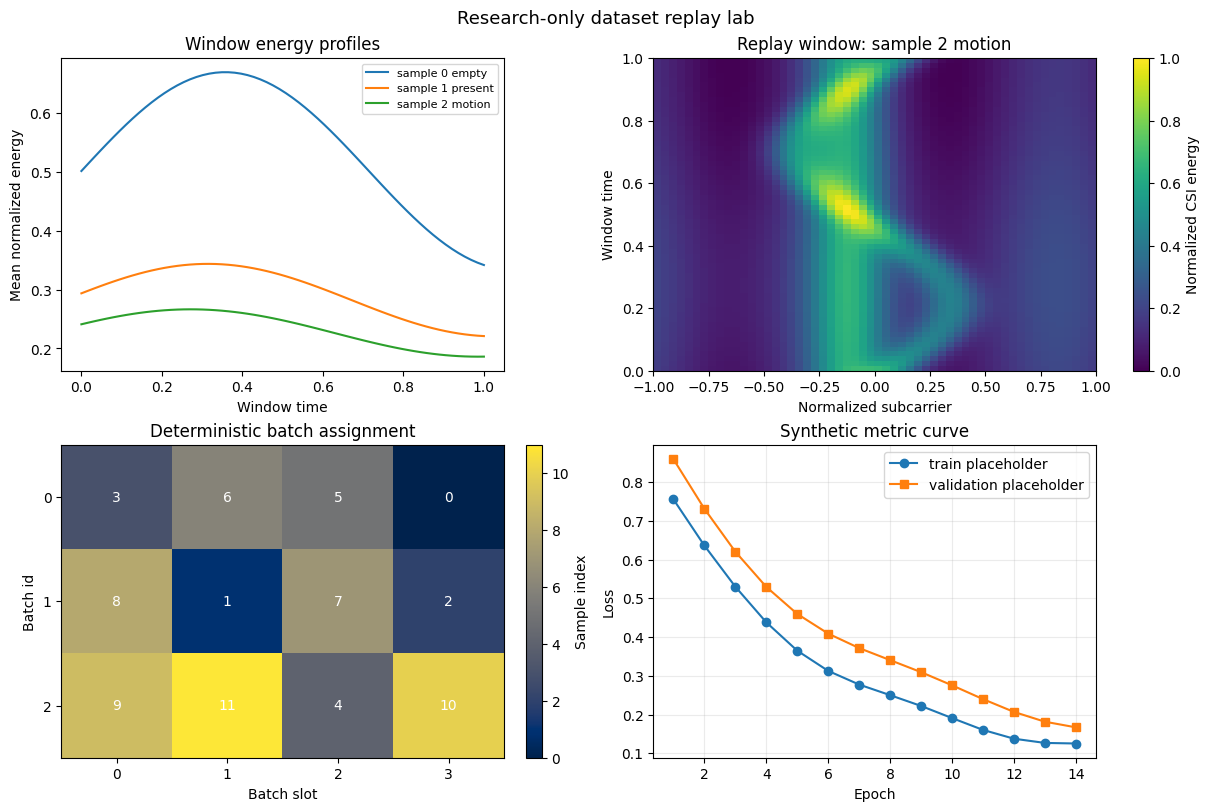

{'batch_order': [[3, 6, 5, 0], [8, 1, 7, 2], [9, 11, 4, 10]], 'window_shape': (64, 56)}


In [3]:
dataset = make_replay_dataset(num_samples=12)
batches = deterministic_batches(len(dataset), batch_size=4, seed=42)
epochs, train_loss, val_loss = synthetic_loss_curves()

batch_matrix = np.full((len(batches), max(len(batch) for batch in batches)), np.nan)
for batch_id, batch in enumerate(batches):
    batch_matrix[batch_id, : len(batch)] = batch

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
examples = [dataset[0], dataset[1], dataset[2]]

for example in examples:
    profile = example["window"].mean(axis=1)
    axes[0, 0].plot(example["time"], profile, label=f"sample {example['sample_idx']} {example['state']}")
axes[0, 0].set_title("Window energy profiles")
axes[0, 0].set_xlabel("Window time")
axes[0, 0].set_ylabel("Mean normalized energy")
axes[0, 0].legend(loc="upper right", fontsize=8)

motion_example = dataset[2]
im1 = axes[0, 1].imshow(
    motion_example["window"],
    aspect="auto",
    origin="lower",
    extent=[motion_example["subcarrier"].min(), motion_example["subcarrier"].max(), 0.0, 1.0],
    cmap="viridis",
)
axes[0, 1].set_title("Replay window: sample 2 motion")
axes[0, 1].set_xlabel("Normalized subcarrier")
axes[0, 1].set_ylabel("Window time")
fig.colorbar(im1, ax=axes[0, 1], label="Normalized CSI energy")

im2 = axes[1, 0].imshow(batch_matrix, aspect="auto", cmap="cividis")
for row in range(batch_matrix.shape[0]):
    for col in range(batch_matrix.shape[1]):
        value = batch_matrix[row, col]
        if np.isfinite(value):
            axes[1, 0].text(col, row, str(int(value)), ha="center", va="center", color="white", fontsize=10)
axes[1, 0].set_title("Deterministic batch assignment")
axes[1, 0].set_xlabel("Batch slot")
axes[1, 0].set_ylabel("Batch id")
axes[1, 0].set_xticks(np.arange(batch_matrix.shape[1]))
axes[1, 0].set_yticks(np.arange(batch_matrix.shape[0]))
fig.colorbar(im2, ax=axes[1, 0], label="Sample index")

axes[1, 1].plot(epochs, train_loss, marker="o", label="train placeholder")
axes[1, 1].plot(epochs, val_loss, marker="s", label="validation placeholder")
axes[1, 1].set_title("Synthetic metric curve")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend(loc="upper right")
axes[1, 1].grid(True, alpha=0.25)

fig.suptitle("Research-only dataset replay lab", fontsize=13)
plt.show()

print({"batch_order": batches, "window_shape": dataset[0]["window"].shape})


Expected interpretation: rerunning the notebook should produce the same window shapes, batch order, and loss curves. This mirrors the Rust training crate's emphasis on deterministic synthetic data and seeded loaders without invoking a trainer.

Limitations: this replay lab does not implement MM-Fi file discovery, subcarrier interpolation, PCK/OKS validation, gradient clipping, checkpoint ranking, or PyTorch training.
